In [1]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from functions import *

Train data

In [157]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage 4')

In [158]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl4_pb2-4-0.jpg,0.833504,2.619537,33.219262,1.730078
1,rl4_pb2-4-1.jpg,0.887509,2.931426,32.981170,1.168411
2,rl4_pb2-4-10.jpg,0.725732,2.732019,33.281558,1.087848
3,rl4_pb2-4-11.jpg,0.691800,3.337727,33.420817,1.439762
4,rl4_pb2-4-12.jpg,0.169617,3.344905,32.834876,1.429773
...,...,...,...,...,...
632,rl4_pb8-7-59.jpg,1.442083,10.630459,51.120596,4.017762
633,rl4_pb8-7-6.jpg,1.046189,9.852765,50.415038,3.788850
634,rl4_pb8-7-7.jpg,0.509980,10.441612,50.741442,4.159621
635,rl4_pb8-7-8.jpg,1.248859,10.505384,51.127469,4.031793


In [111]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [112]:
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])

In [113]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [114]:
fft_features.shape

(637, 400)

In [115]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((637,), (637,), (637,), (637,))

In [116]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [117]:
labels.shape

(637, 4)

SVM with FFT and PCA

In [119]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

Linear Regression with FFT and PCA

In [120]:
lr = LinearRegression()
mlr = MultiOutputRegressor(lr)
mlr.fit(fft_features, labels)

MultiOutputRegressor(estimator=LinearRegression())

XGBoost with FFT and PCA

In [121]:
xgb = XGBRegressor()
mxgb = MultiOutputRegressor(xgb)
mxgb.fit(fft_features, labels)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...))

Catboost with FFT and PCA

In [176]:
cbr = cb.CatBoostRegressor()
mcb = MultiOutputRegressor(cbr)
mcb.fit(fft_features, labels, verbose=False)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x000001E38D8F2700>)

Random Forest with FFT and PCA

In [186]:
rf = RandomForestRegressor()
mrf = MultiOutputRegressor(rf)
mrf.fit(fft_features, labels)

MultiOutputRegressor(estimator=RandomForestRegressor())

dep data

In [160]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage 4')

In [161]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl4_pb12-4-0.jpg,2.132586,11.764315,50.109464,5.306501
1,rl4_pb12-4-1.jpg,2.537339,10.976026,49.908291,5.683570
2,rl4_pb12-4-10.jpg,1.706078,11.423658,50.027161,5.252946
3,rl4_pb12-4-11.jpg,2.126002,11.567778,50.323573,5.664201
4,rl4_pb12-4-12.jpg,1.878492,11.301071,50.342798,5.413641
...,...,...,...,...,...
132,rl4_pb30-6-60.jpg,2.717827,6.663965,58.163071,1.578673
133,rl4_pb30-6-61.jpg,2.394946,6.199267,58.340415,1.401061
134,rl4_pb30-6-7.jpg,2.397697,6.450840,58.397100,1.378827
135,rl4_pb30-6-8.jpg,2.084260,6.384199,58.117239,2.061398


In [126]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [127]:
for line in df_test.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_cu.append(line[1])
    test_labels_fe.append(line[2])
    test_labels_pb.append(line[3])
    test_labels_zn.append(line[4])

In [128]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [129]:
test_fft_features.shape

(137, 400)

In [130]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((137,), (137,), (137,), (137,))

In [131]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [132]:
test_labels.shape

(137, 4)

SVM

In [133]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 2.435330051894045
MSE 9.757343980631727
R2 Score -2.086871158524419


In [179]:
pickle.dump(msvm, open("./models/svm_model", 'wb'))

XGBoost

In [134]:
y_pred = mxgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 2.9132242885665973
MSE 15.235687631061419
R2 Score -2.2392148139434562


In [181]:
pickle.dump(mxgb, open("./models/xgboost_model", 'wb'))

Linear Regression

In [135]:
y_pred = mlr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 3.0636314285515702
MSE 20.919044818442305
R2 Score -3.3801332224117777


In [182]:
pickle.dump(mlr, open("./models/linear_regression_model", 'wb'))

Catboost

In [177]:
y_pred = mcb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 2.764850749223476
MSE 12.476862032866185
R2 Score -1.7395432326156046


In [183]:
pickle.dump(mcb, open("./models/catboost_model", 'wb'))

Random Forest

In [187]:
y_pred = mrf.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 2.6922277270714345
MSE 11.398439888780892
R2 Score -1.5353012186681176


In [188]:
pickle.dump(mrf, open("./models/random_forest_model", 'wb'))

# Test Video #1

In [35]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "DataSource.xlsx")

SVM

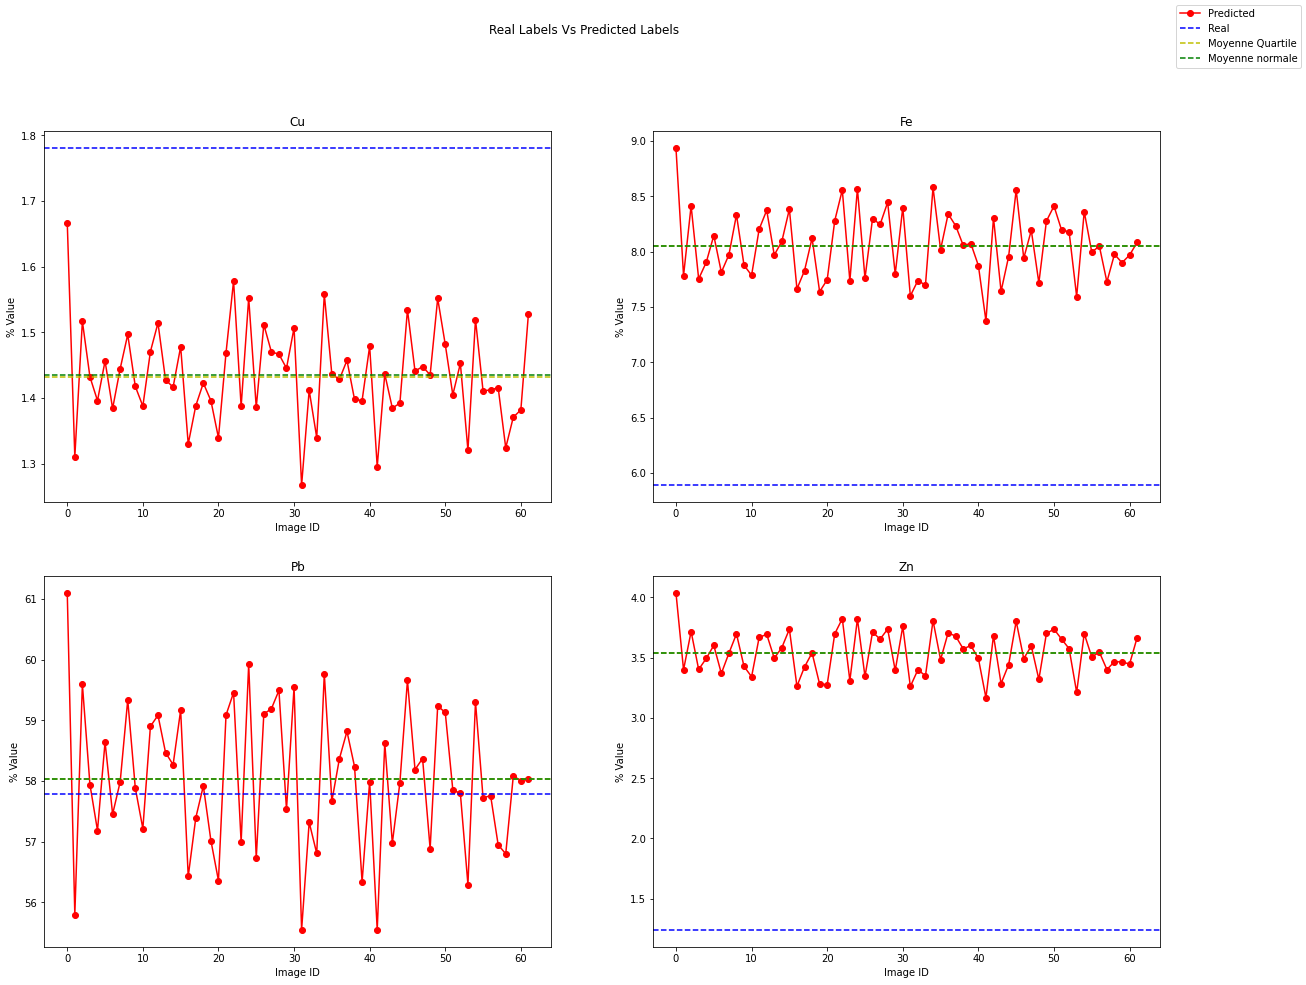

In [36]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [44]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.3487157497591482
Fe: 2.164624481169805
Pb: 0.2540961324447082
Zn: 2.2995038460805253


Random Forest

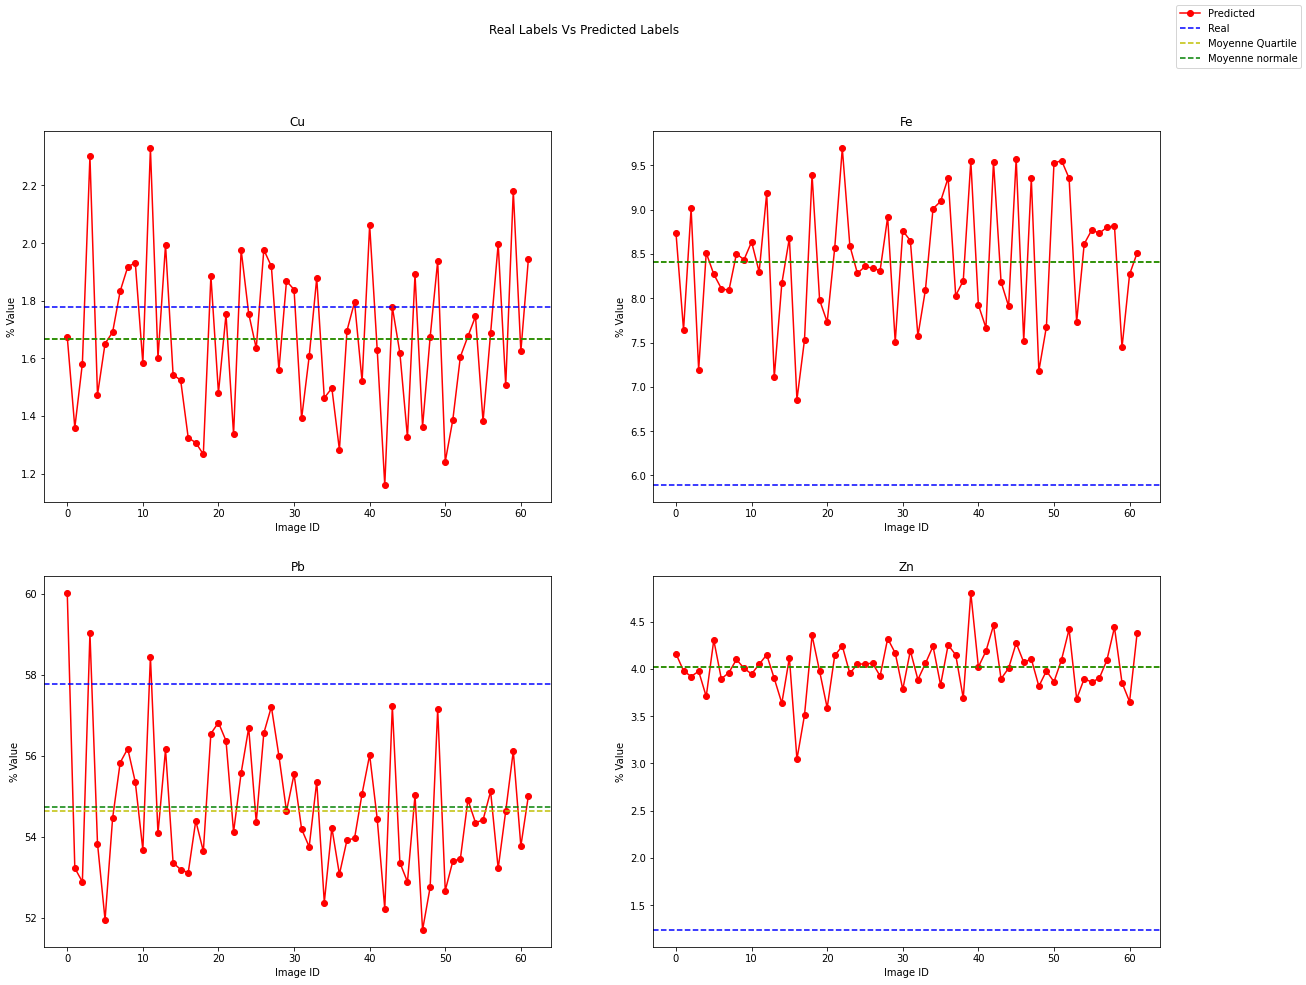

In [45]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [46]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.1116226876441353
Fe: 2.523514767843481
Pb: 3.1425379368545165
Zn: 2.779672034595344


XGBoost

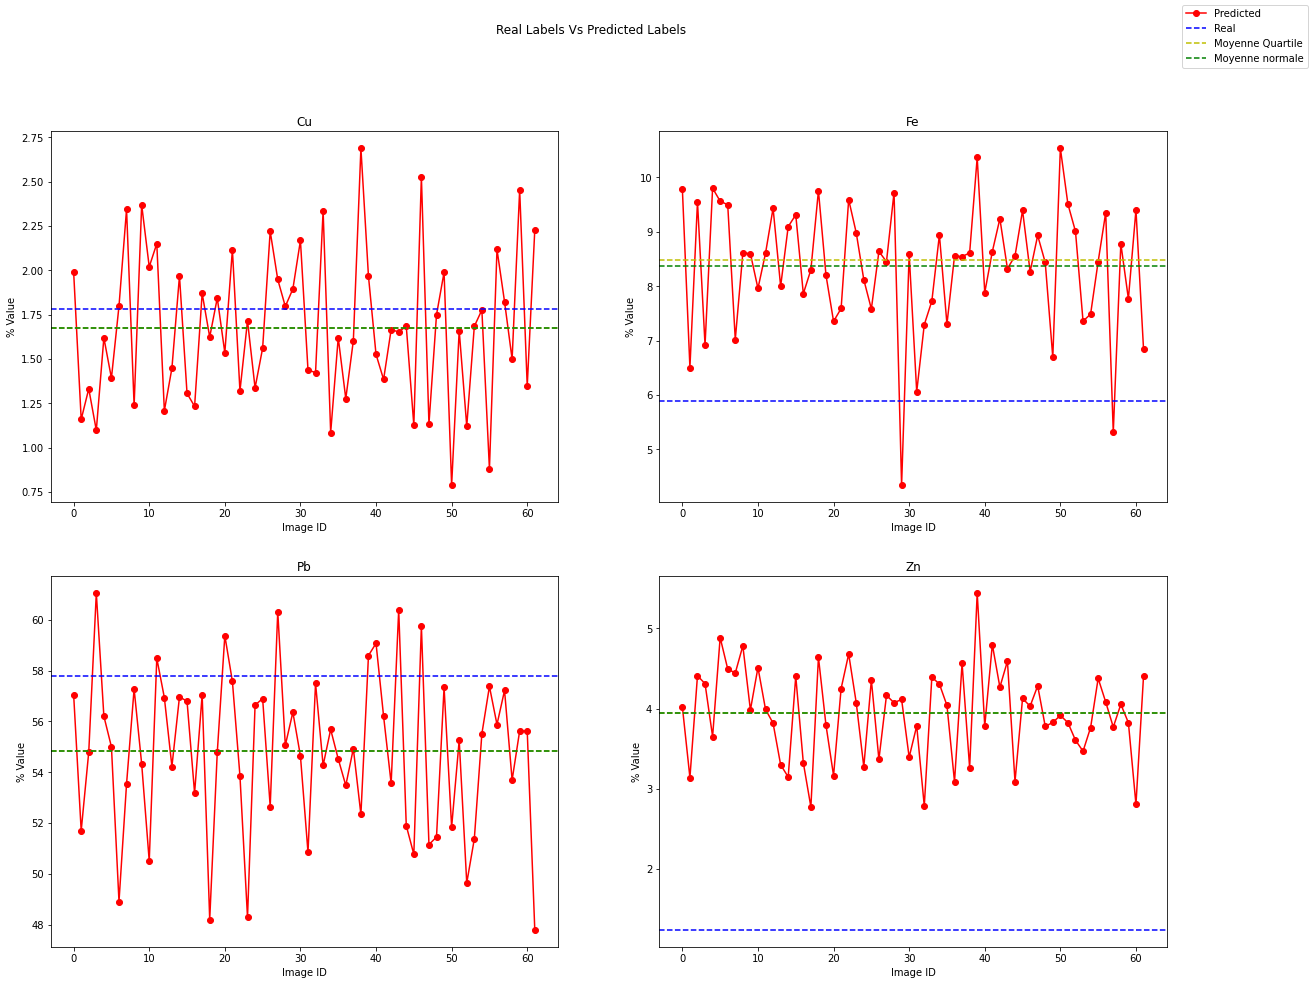

In [47]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [48]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.10400000095367434
Fe: 2.5975631332397464
Pb: 2.9564907836914074
Zn: 2.7085859870910642


Catboost

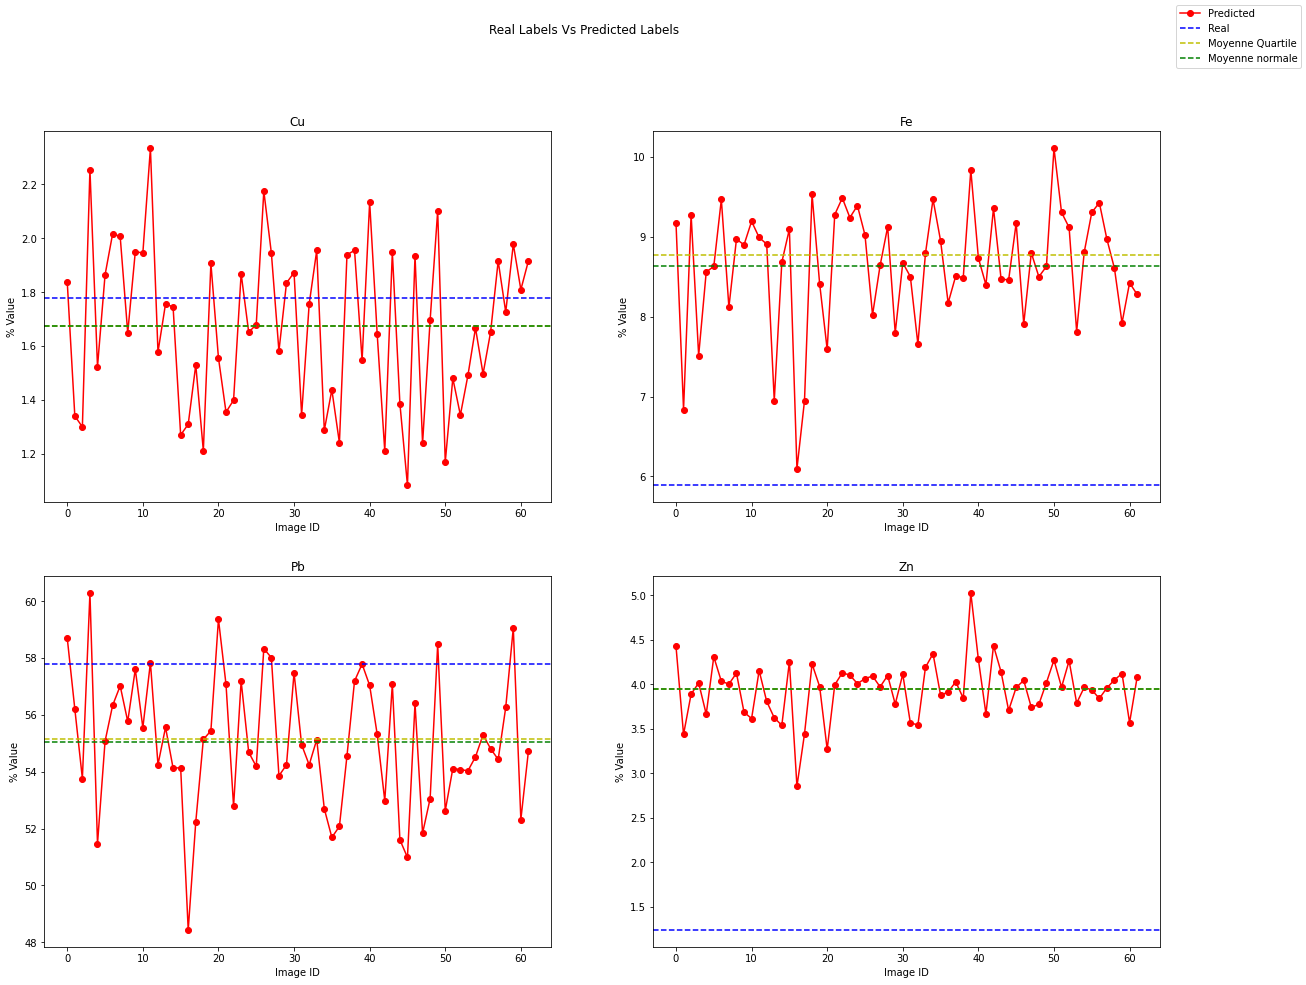

In [49]:
Teneur_predit = predict_video("../video_test/rl4_pb30-6.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [50]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.10704255235395244
Fe: 2.878538790369366
Pb: 2.614486133858101
Zn: 2.704238869550654


# Test Video #2

In [51]:
TeunneurReel = TenneurReel("rl4_pb12-4.mp4", "DataSource.xlsx")

SVM

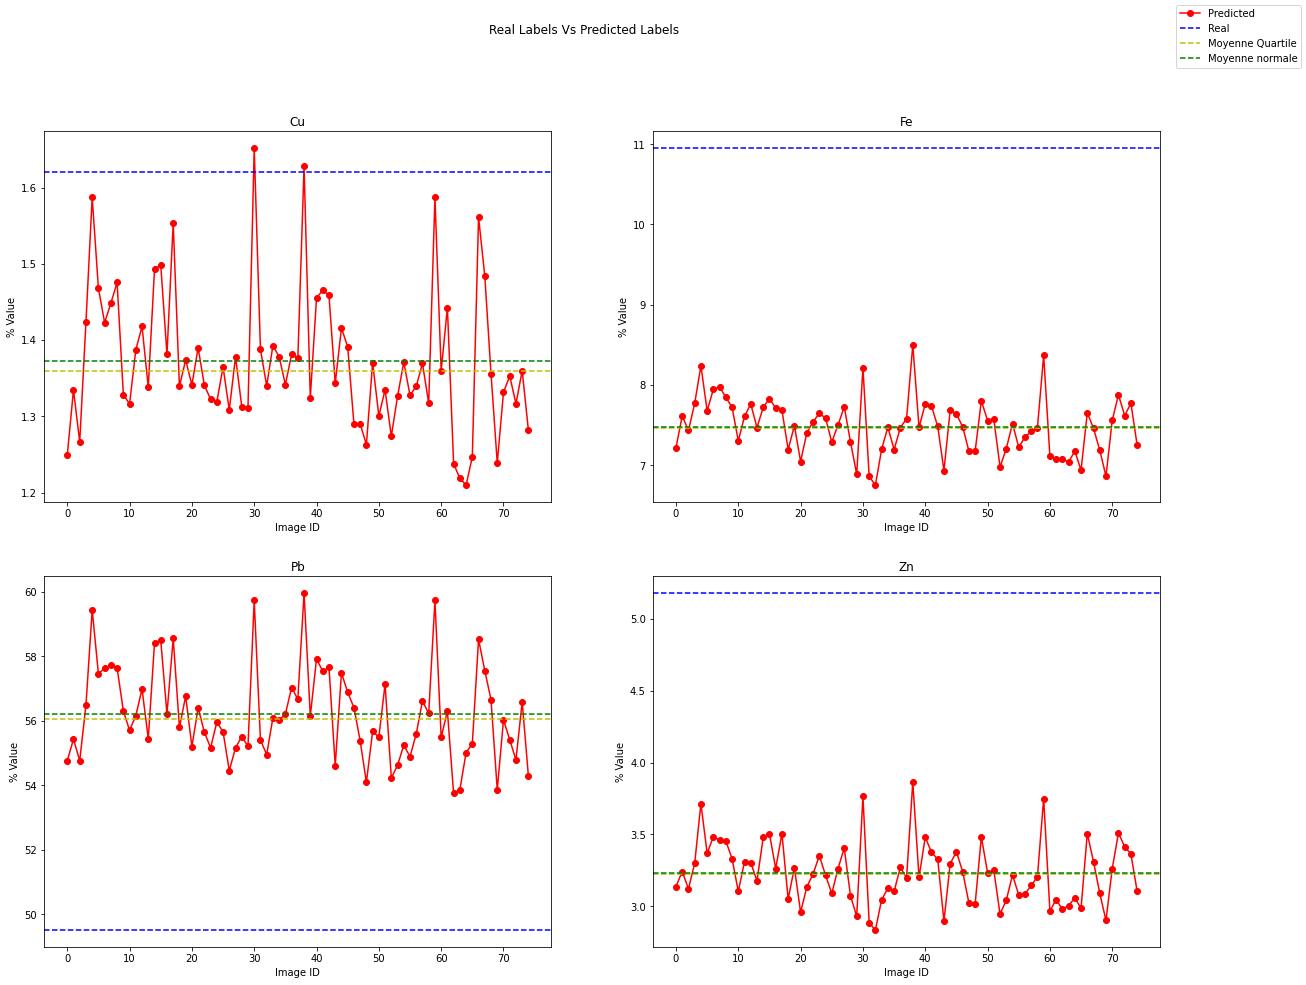

In [52]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [53]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.2605107417783945
Fe: 3.483039738750045
Pb: 6.537883192265056
Zn: 1.9552279355831104


Random Forest

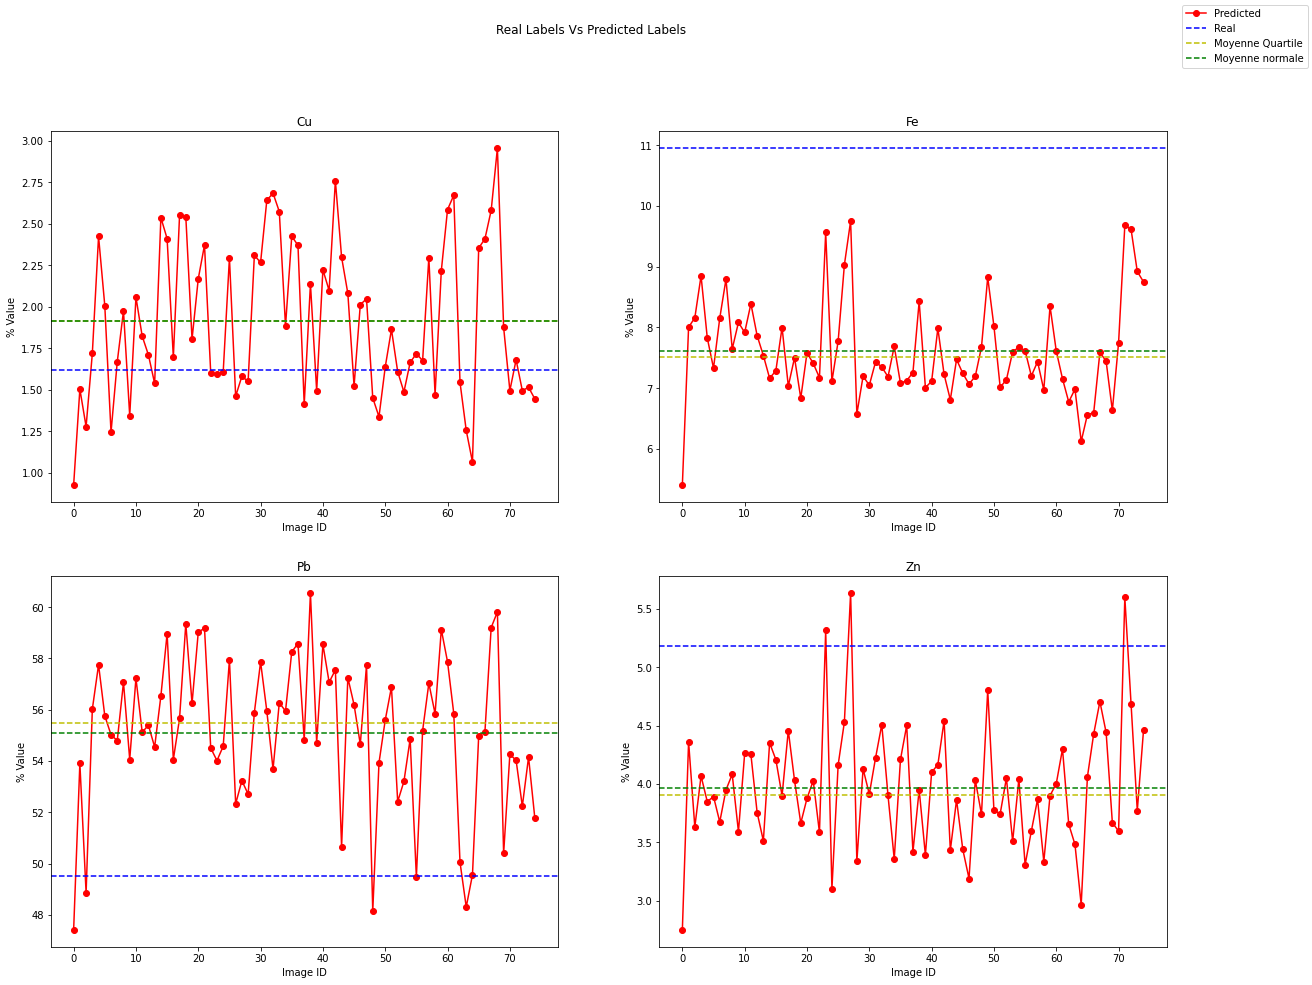

In [54]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [55]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.29557821927818795
Fe: 3.429985289513519
Pb: 5.974920707608263
Zn: 1.2758928334458952


XGBoost

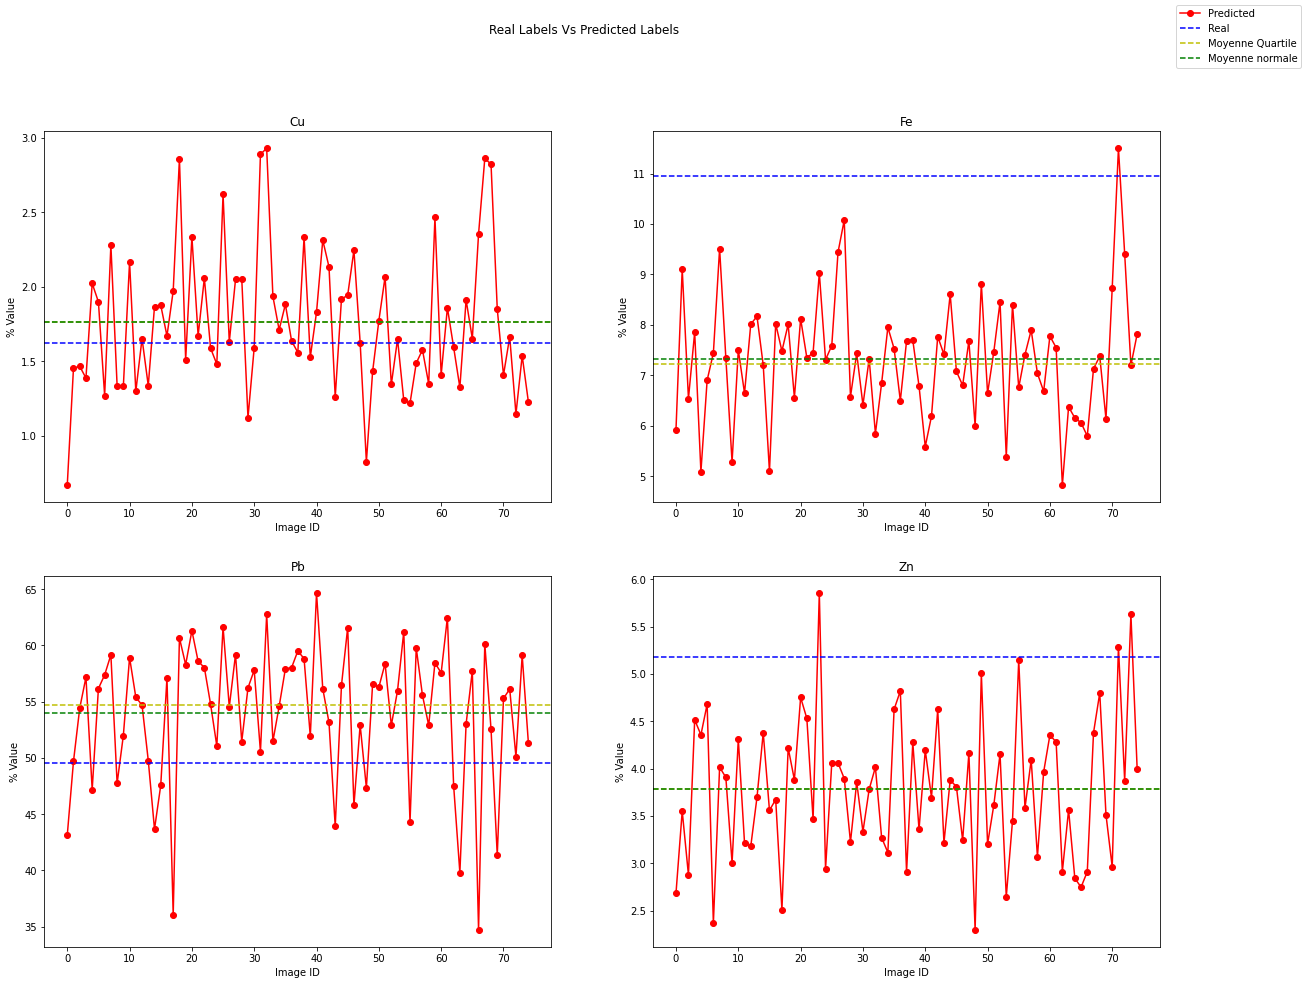

In [56]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [57]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.14355016231536855
Fe: 3.7302147865295403
Pb: 5.186707000732419
Zn: 1.3944560813903806


Catboost

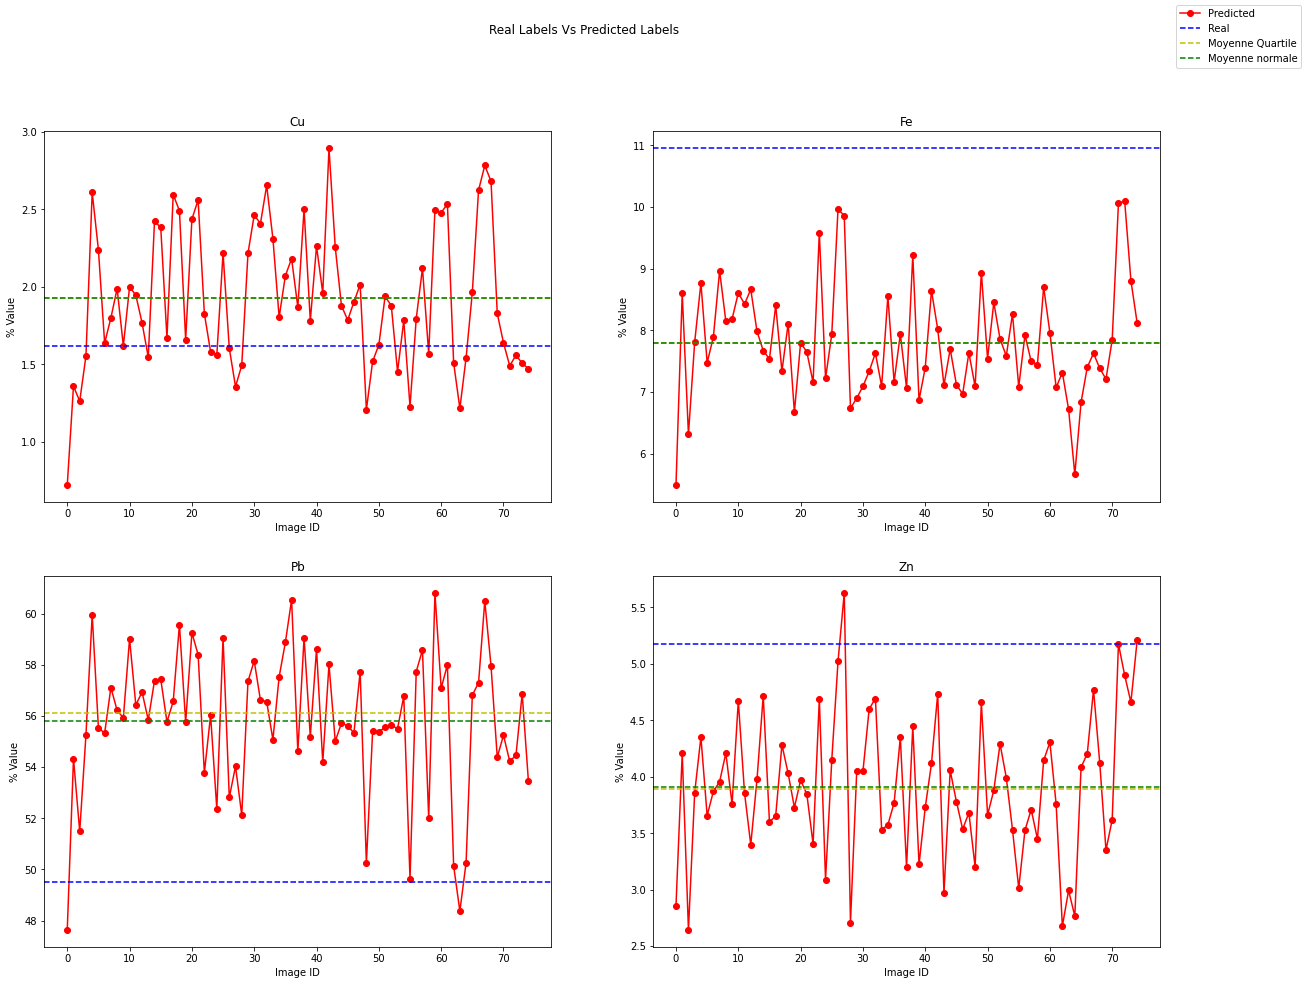

In [58]:
Teneur_predit = predict_video("../video_test/rl4_pb12-4.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [59]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.3076754647706865
Fe: 3.153717763101996
Pb: 6.585169193538313
Zn: 1.2893940912862085


# Dep Video

In [2]:
msvm = pickle.load(open("./models/svm_model", 'rb'))
mxgb = pickle.load(open("./models/xgboost_model", 'rb'))
mcb = pickle.load(open("./models/catboost_model", 'rb'))
mrf = pickle.load(open("./models/random_forest_model", 'rb'))

In [14]:
TeunneurReel = TenneurReel("rl4_pb15-7.mp4", "DataSource.xlsx")

SVM

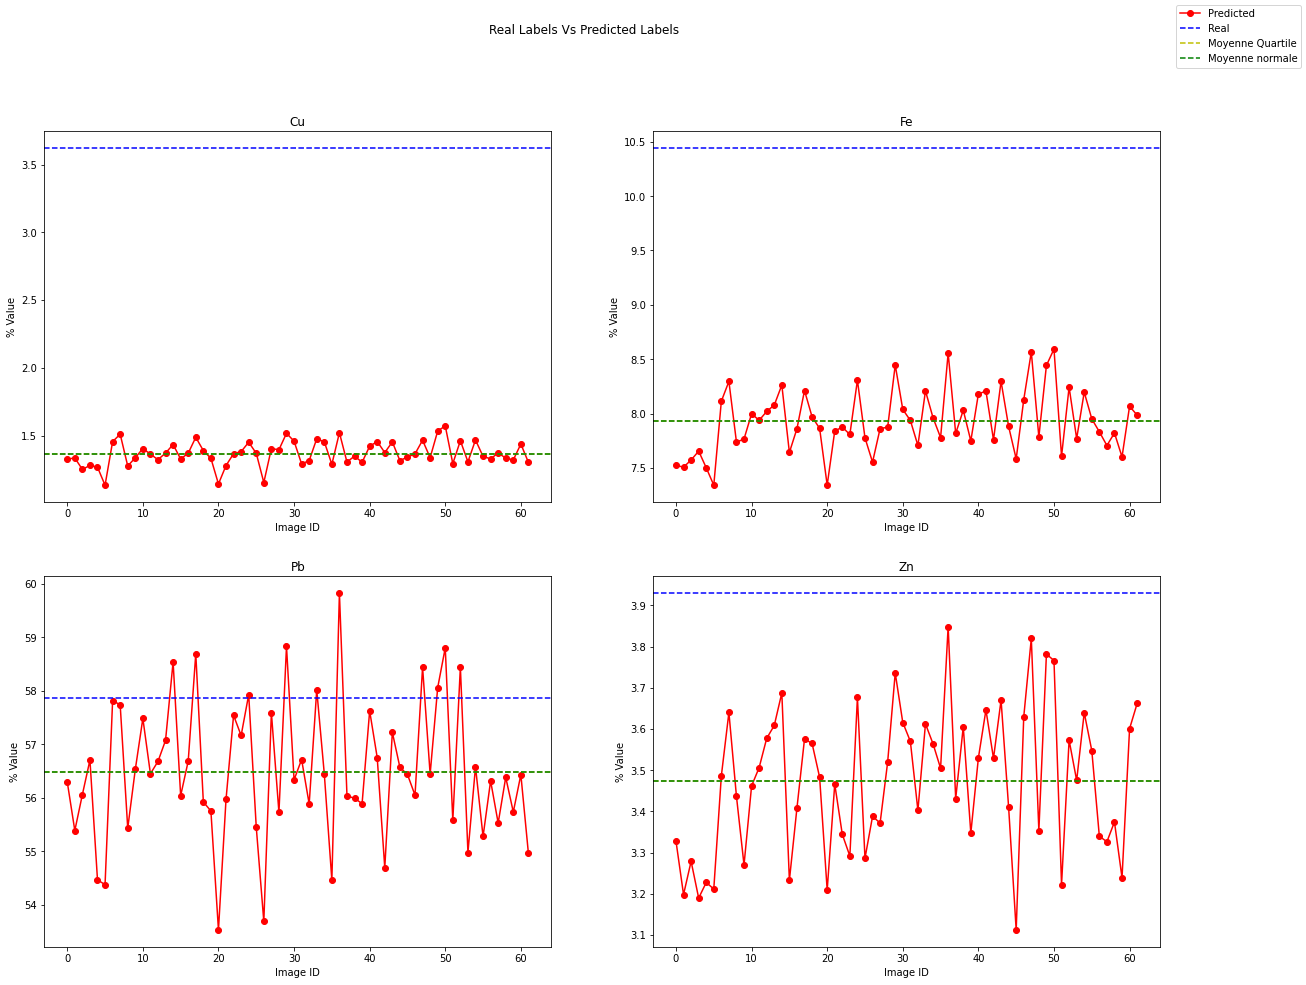

In [15]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", msvm)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Random Forest

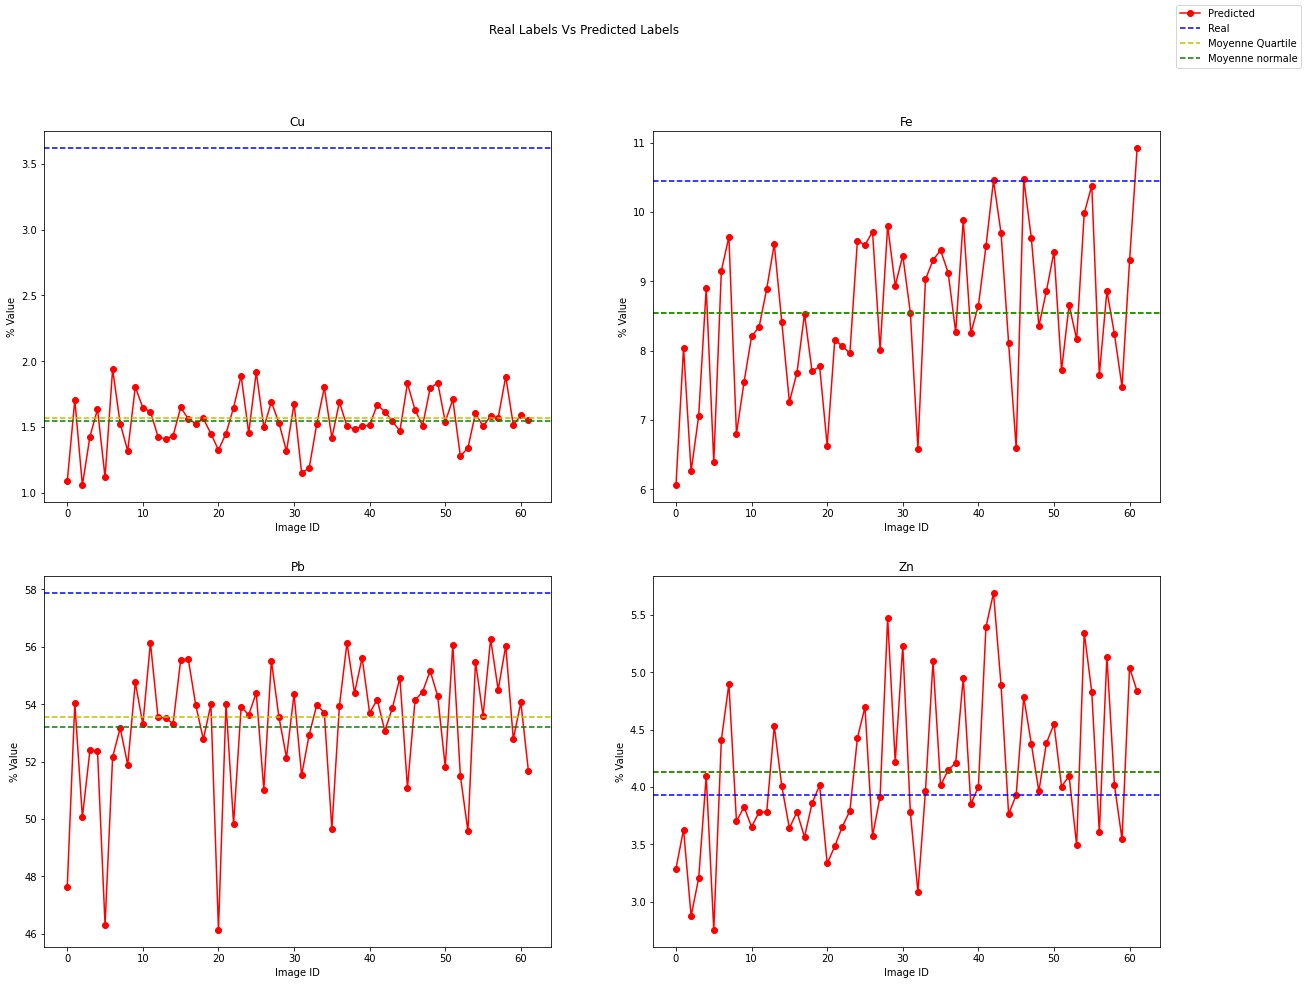

In [16]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mrf)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

XGBoost

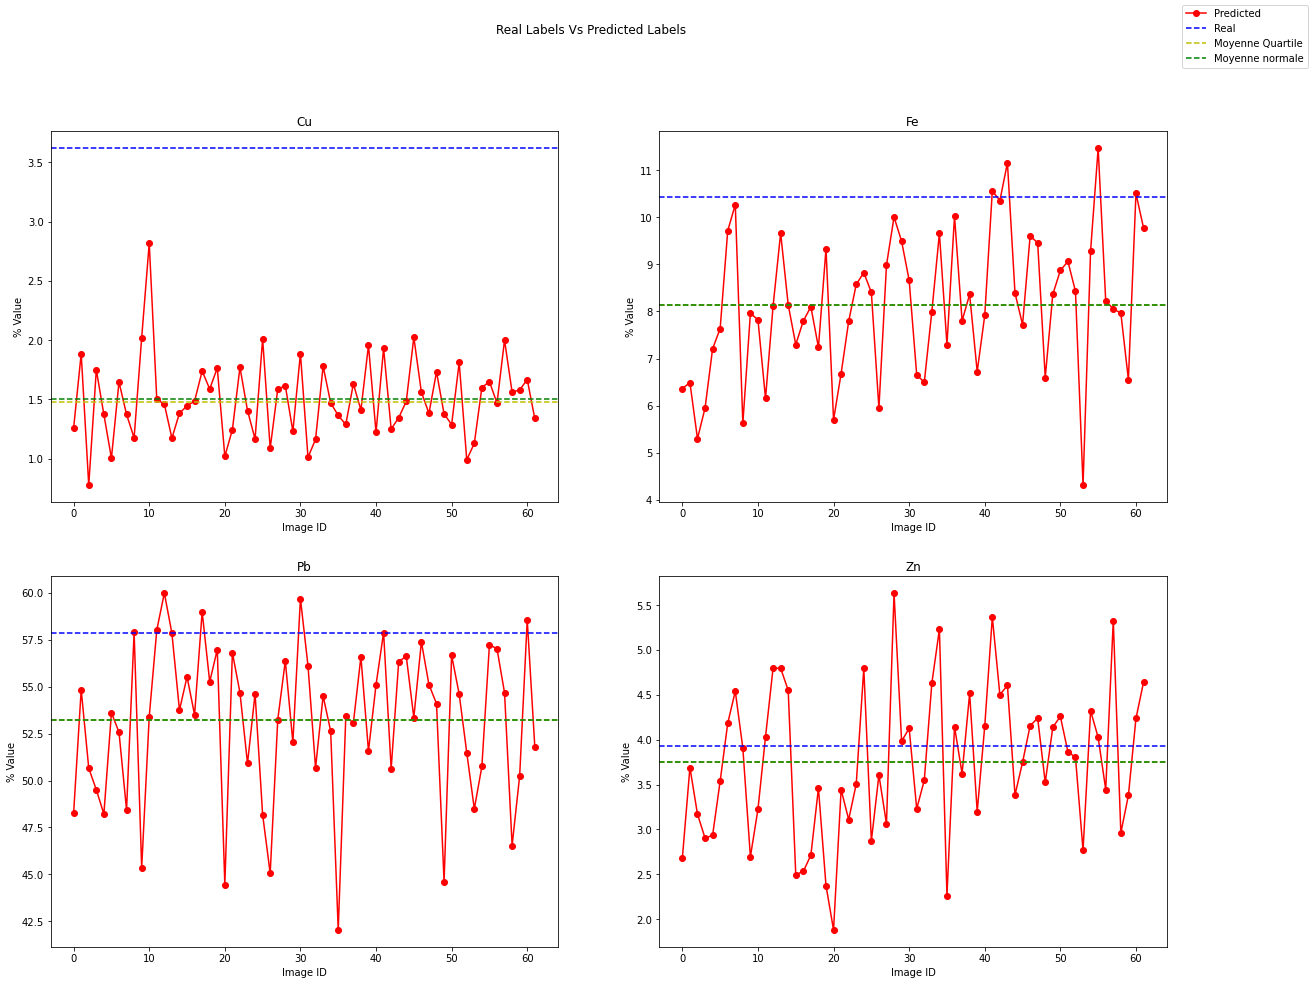

In [17]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mxgb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

Catboost

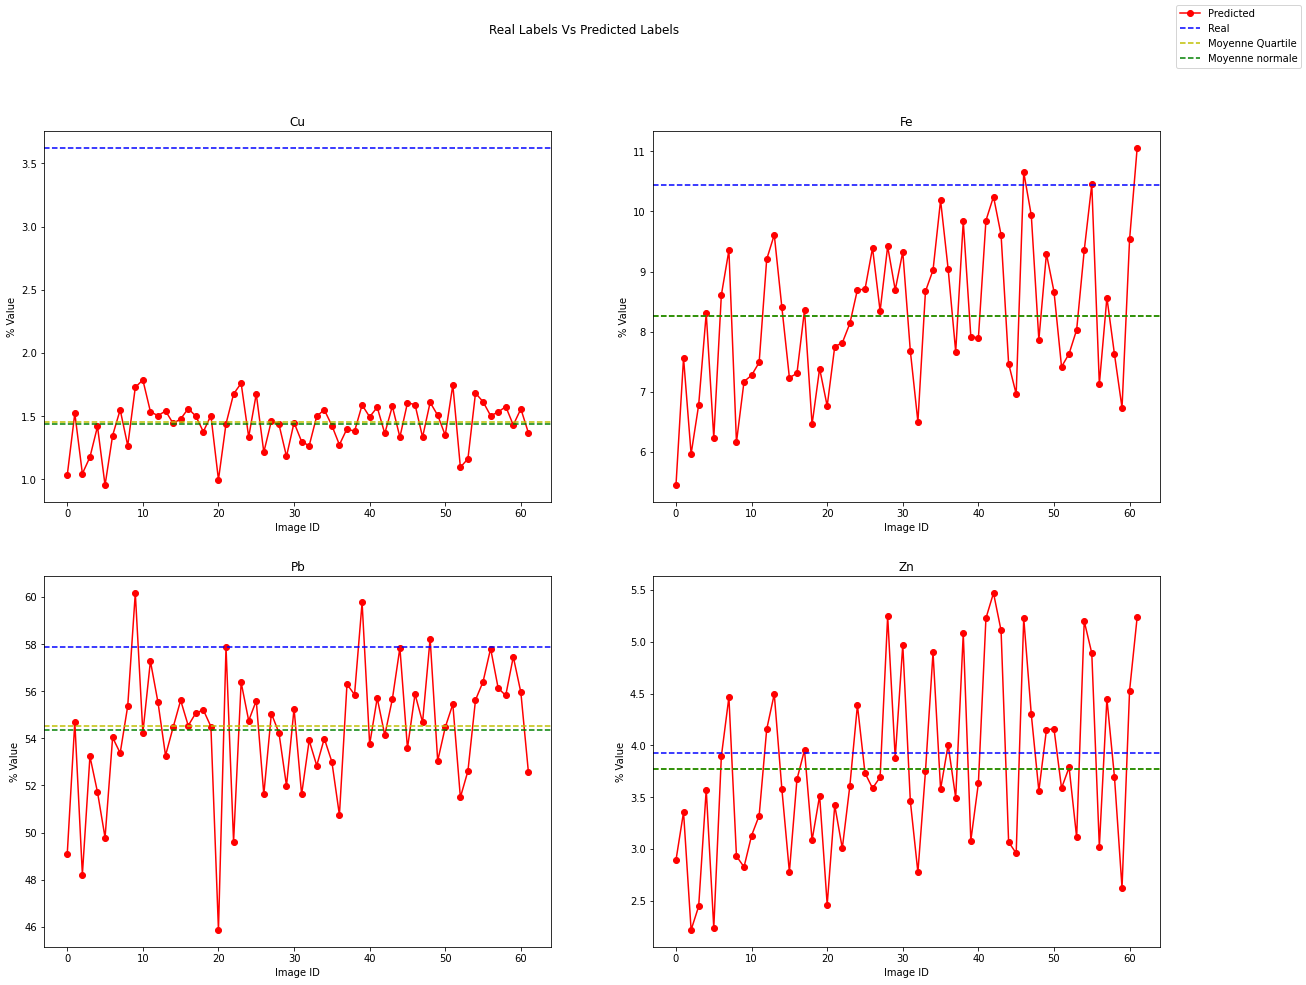

In [18]:
Teneur_predit = predict_video("../video_dep/rl4_pb15-7.mp4", mcb)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)